In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


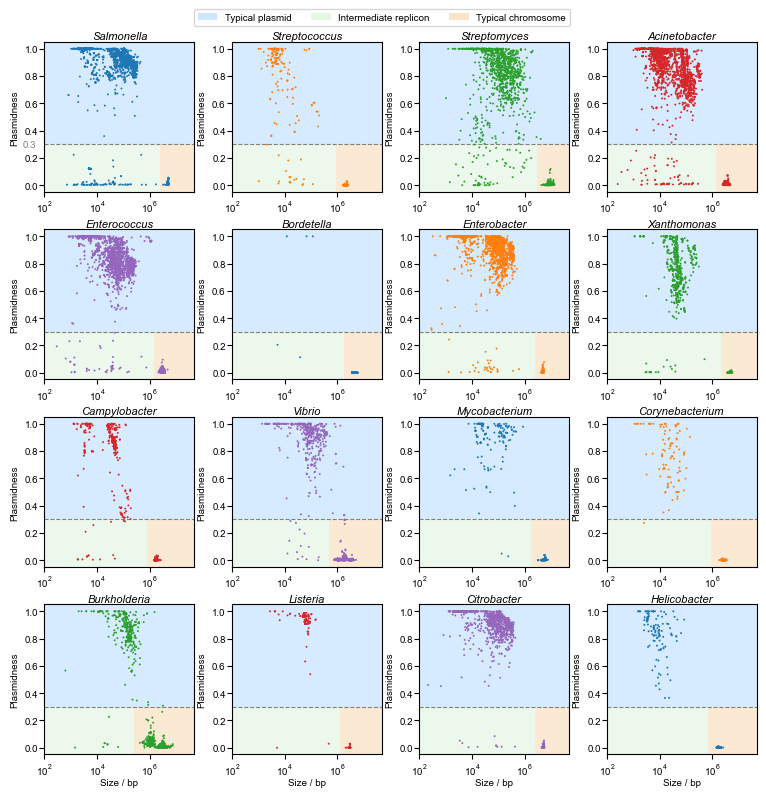

In [2]:
import ast
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

label = 'pident_90'
os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

def process_replicon_data(fraction_data):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

top_5_genus = keep_genus[:5]
single_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
remaining_genus = [g for g in keep_genus if g not in top_5_genus]

fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.05
split_size = 1/4
length = split_size - gap

axes = []
for i, genus_name in enumerate(remaining_genus):
    left = gap + split_size * (i % 4)
    bottom = 1 - length - split_size * int(i / 4)
    ax = fig.add_axes([left, bottom, length, length])
    axes.append((i, genus_name, ax))

for idx, genus_name, ax in axes:
    folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    os.chdir(folder)
    df = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')

    ax.scatter(df['size'], df['average plasmid fraction-pident_90'], c=single_colors[idx % len(single_colors)],
        edgecolors='none', s=2, alpha=1, zorder=3
    )
    row_idx = idx // 4

    if row_idx == 3:
        ax.set_xlabel('Size / bp', labelpad=1)

    ax.set_ylabel('Plasmidness')
    ax.set_xscale('log')
    ax.set_title(genus_name, fontproperties=title_font, pad=2)
    ax.set_xlim(100, 5e7)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', pad=1)

    size_split = process_replicon_data(df)
    x_min, x_max = 100, 5e7
    y_min, y_max = -0.1, 1.1
    threshold = 0.3

    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect3)

    ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)
    if idx == 0:
        ax.text(5e1, threshold, '0.3', va='center', ha='right', fontsize=7, color='gray')

legend_elements = [
    Patch(facecolor='#cce7ff', alpha=1, label='Typical plasmid'),
    Patch(facecolor='#e6f7e6', alpha=1, label='Intermediate replicon'),
    Patch(facecolor='#f9e4c8', alpha=1, label='Typical chromosome')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.015), prop=font_prop, frameon=True, ncol=3)

figure_fold = '/active-data/analysis_results/chr_pla/genus/figures/scatter_plot'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig("S_Remaining_16_genus_4x4_layout.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_Remaining_16_genus_4x4_layout.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()

In [3]:
def process_replicon_data(fraction_data, label = 'pident_90'):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

def scatter_figure(ax, df, title_text, ref_df, label = 'pident_90', color='gray', alpha=1):
    ax.scatter(
        df['size'],
        df[f'average plasmid fraction-{label}'],
        c=color,
        edgecolors='none',
        s=5, alpha=alpha, zorder=3
    )

    ax.set_xlabel('Size / bp', labelpad=0)
    ax.set_ylabel('Plasmidness', labelpad=0)
    ax.set_xscale('log')
    ax.set_title(title_text)
    ax.set_xlim(100, 5e7)
    ax.tick_params(axis='both')
    
    size_split = process_replicon_data(ref_df, label)
    x_min, x_max = 100, 5e7
    y_min, y_max = -0.1, 1.1
    threshold = 0.3
    ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)
    
    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax.add_patch(rect3)

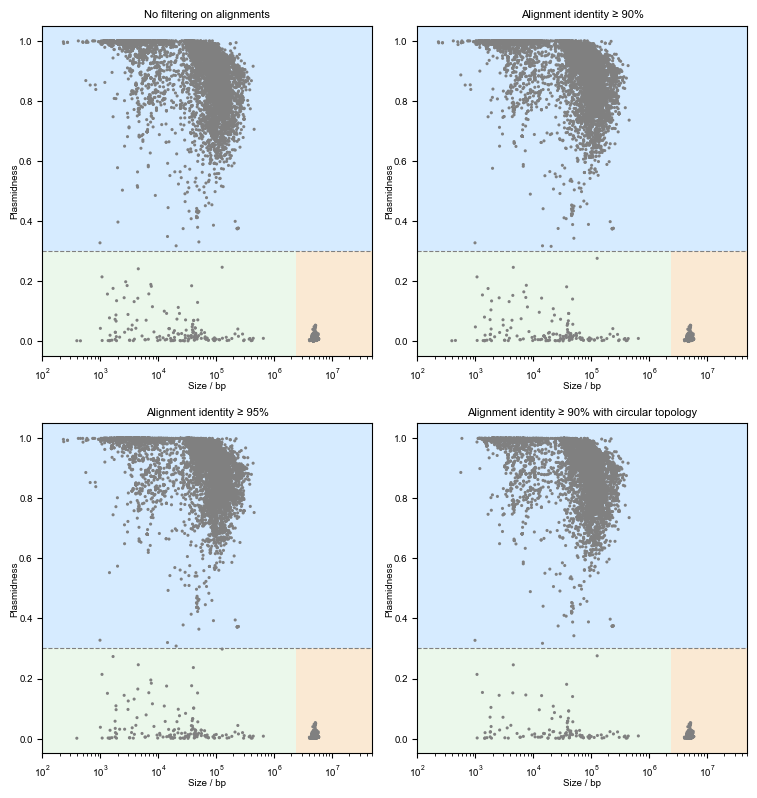

In [4]:
genus_name = 'Escherichia'

folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
os.chdir(folder)
contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
fig = plt.figure(figsize=(7.5, 7.5))
gap = 0.06
split_size = 1/2
length = split_size - gap
ax1 = fig.add_axes([gap, 1-length, length, length])
ax2 = fig.add_axes([gap+split_size, 1-length, length, length])
ax3 = fig.add_axes([gap, 1-length-(0.03+split_size), length, length])
ax4 = fig.add_axes([gap+split_size, 1-length-(0.03+split_size), length, length])

scatter_figure(ax1, contig_info, 'No filtering on alignments', contig_info, label = 'original')
scatter_figure(ax2, contig_info, 'Alignment identity ≥ 90%', contig_info, label = 'pident_90')
scatter_figure(ax3, contig_info, 'Alignment identity ≥ 95%', contig_info, label = 'pident_95')
scatter_figure(ax4, contig_info[contig_info['topology']=='circular'], 'Alignment identity ≥ 90% with circular topology', contig_info, label = 'pident_90')

os.chdir("/active-data/analysis_results/chr_pla/genus/figures/scatter_plot")
plt.savefig("S_identity_filtering.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_identity_filtering.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()